# Proyek Analisis Data: Brazilian E-Commerce
- **Nama:** Muhammad Ichsan Firdaus
- **Email:** m011b4ky2896@bangkit.academy
- **ID Dicoding:** ichsanfrds

## Menentukan Pertanyaan Bisnis

(RFM)
- **Kota Apa** yang memiliki pelanggan terbanyak yang telah melakukan *Recent Purchase(s)* setidaknya dalam kurun waktu 1 bulan terakhir?
- Bagaimana **Performa Penjualan Produk** dalam kurun tahun 2016 - 2018?
- **Kategori Produk Apa** yang menghasilkan **Pendapatan Terbanyak** dalam kurun waktu 6 bulan terakhir?

## Import Semua Packages/Library yang Digunakan

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

1. **Inisialisasi Dataframe** dari setiap Dataset CSV

In [7]:
base_dir = os.path.join(os.getcwd(), "Raw_Dataset")

customers_df = pd.read_csv(os.path.join(base_dir, "olist_customers_dataset.csv"))
order_items_df = pd.read_csv(os.path.join(base_dir, "olist_order_items_dataset.csv"))
order_payments_df = pd.read_csv(os.path.join(base_dir, "olist_order_payments_dataset.csv"))
orders_df = pd.read_csv(os.path.join(base_dir, "olist_orders_dataset.csv"))
products_df = pd.read_csv(os.path.join(base_dir, "olist_products_dataset.csv"))
product_category_name_translation_df = pd.read_csv(os.path.join(base_dir, "product_category_name_translation.csv"))

**Insight:**
- Dataset Berjudul "Brazilian E-Commerce Public Dataset by Olist" didapatkan dari **Kaggle** yang berjumlah 9 File CSV
- Dihasilkan 6 Dataframe dari 6 File CSV terpilih
- customer_df berisi informasi terkait **Customer** yang berisi ID Customer, ID Unique Customer, ZIP Code Customer, Kota Customer, State Customer
- order_items_df berisi informasi terkait **Barang yang di Order** yang berisi ID Order, ID Order Item, ID Product, ID Seller, Waktu Limit Shipping, Harga,Ongkos Kirim
- order_payments_df berisi informasi terkait **Pembayaran Order** yang berisi ID Order, Sequence Pembayaran, Metode Pembayaran, *Payment Installments*, Harga Bayar
- orders_df berisi informasi terkait **Pesanan Pelanggan** yang berisi ID Order, ID Customer, Status Pemesanan, Waktu Pemesanan Dilakukan,Waktu Pemesanan Diterima, Waktu Order Dibawa Kurir, Waktu Order Sampai Ke Pelanggan, Estimasi Waktu Pengiriman
- products_df berisi informasi terkait **Produk** yang berisi ID Produk,Kategori Produk, Panjang Nama Produk, Panjang Deskripsi Produk, Kuantitas Foto Produk, Berat Produk (g), Panjang Produk (cm), Tinggi Produk (cm), Lebar Produk (cm)
- product_category_name_translation_df berisi informasi terkait **Kategori Produk Dalam Bahasa Inggris** yang berisi Kategori Produk (Brazil) dan Kategori Produk (Inggris)

### Assessing Data

#### 1. Pengecekan *Potential Problems* pada Dataframe

Customers_df
- Keseluruhan AMAN

In [8]:
customers_df.info()
print("Jumlah duplikasi: ", customers_df.duplicated().sum())
customers_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


order_items_df
- Keseluruhan AMAN

CLEANING
- **Dropping** Kolom shipping_limit_date, price, freight_value karena tidak mempengaruhi jawaban pertanyaan bisnis kita

In [9]:
order_items_df.info()
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())
order_items_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


order_payments_df
- Keseluruhan AMAN

CLEANING
- **Dropping** Kolom payment_sequential, payment_type, payment_installments karena tidak mempengaruhi jawaban pertanyaan bisnis kita

In [10]:
order_payments_df.info()
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())
order_payments_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
Jumlah duplikasi:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


orders_df
- Terdapat beberapa Pesanan yang Belum diapprove, belum dibawa kurir, dan belum sampai di customer (Tidak mempengaruhi Data Jumlah Pembelian dan Penghasilan karena order_purchase_timestamp tidak memiliki missing values yang artinya keseluruhan order telah dibayar)
- Terdapat 625 Order yang dicancel dan 609 Order yang unavailable (Akan dilakukan Row **Dropping** saat Cleaning Data)

CLEANING
- **Dropping** Kolom order_status, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date karena tidak mempengaruhi jawaban pertanyaan bisnis kita
- **Pengubahan Tipe Data** order_approved_at menjadi date
- **Dropping Outlier** Tahun 2016

In [11]:
orders_df.info()
print("Jumlah duplikasi: ", orders_df.duplicated().sum())
orders_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Menampilkan Berapa Baris yang memiliki data kosong pada kolom terkait

In [12]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [13]:
order_status_types = orders_df['order_status'].unique()
print("Jenis-jenis order_status:", order_status_types)

Jenis-jenis order_status: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']


Menampilkan Jumlah Order yang unavailable

In [14]:
unavailable_orders_count = orders_df[orders_df['order_status'] == 'unavailable'].shape[0]
print("Jumlah order yang memiliki status 'unavailable':", unavailable_orders_count)

Jumlah order yang memiliki status 'unavailable': 609


Menampilkan Jumlah Order yang dicancel

In [15]:
canceled_orders_count = orders_df[orders_df['order_status'] == 'canceled'].shape[0]
print("Jumlah order yang memiliki status 'canceled':", canceled_orders_count)

Jumlah order yang memiliki status 'canceled': 625


products_df
- Terdapat 610 Data yang tidak memiliki Kategori Nama (Row tersebut akan di **Drop** Saat Cleaning Data)
- Terdapat 610 Data yang tidak memiliki Panjang Nama, dan Panjang Deskripsi serta Kuantitas Foto (Kolom - Kolom tersebut akan di **Drop** Saat Cleaning Data karena tidak mempengaruhi jawaban akan pertanyaan bisnis kita)
- Terdapat 2 Data yang tidak memiliki Berat dan Panjang Tinggi Lebar Produk (Kolom - Kolom tersebut akan di **Drop** Saat Cleaning Data karena tidak mempengaruhi jawaban akan pertanyaan bisnis kita)

In [16]:
products_df.info()
print("Jumlah duplikasi: ", products_df.duplicated().sum())
products_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
Jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [17]:
missing_product_category = products_df[products_df['product_category_name'].isna()]
print("Data yang tidak memiliki 'product_category_name':")
print(missing_product_category)
missing_count = missing_product_category.shape[0]
print(f"\nJumlah data yang tidak memiliki 'product_category_name': {missing_count}")

Data yang tidak memiliki 'product_category_name':
                             product_id product_category_name  \
105    a41e356c76fab66334f36de622ecbd3a                   NaN   
128    d8dee61c2034d6d075997acef1870e9b                   NaN   
145    56139431d72cd51f19eb9f7dae4d1617                   NaN   
154    46b48281eb6d663ced748f324108c733                   NaN   
197    5fb61f482620cb672f5e586bb132eae9                   NaN   
...                                 ...                   ...   
32515  b0a0c5dd78e644373b199380612c350a                   NaN   
32589  10dbe0fbaa2c505123c17fdc34a63c56                   NaN   
32616  bd2ada37b58ae94cc838b9c0569fecd8                   NaN   
32772  fa51e914046aab32764c41356b9d4ea4                   NaN   
32852  c4ceee876c82b8328e9c293fa0e1989b                   NaN   

       product_name_lenght  product_description_lenght  product_photos_qty  \
105                    NaN                         NaN                 NaN   
128          

In [18]:
missing_weight_data = products_df[products_df['product_weight_g'].isna()]
print("Data yang tidak memiliki 'product_weight_g':")
print(missing_weight_data)

Data yang tidak memiliki 'product_weight_g':
                             product_id product_category_name  \
8578   09ff539a621711667c43eba6a3bd8466                 bebes   
18851  5eb564652db742ff8f28759cd8d2652a                   NaN   

       product_name_lenght  product_description_lenght  product_photos_qty  \
8578                  60.0                       865.0                 3.0   
18851                  NaN                         NaN                 NaN   

       product_weight_g  product_length_cm  product_height_cm  \
8578                NaN                NaN                NaN   
18851               NaN                NaN                NaN   

       product_width_cm  
8578                NaN  
18851               NaN  


product_category_name_translation_df
- Keseluruhan AMAN

In [19]:
product_category_name_translation_df.info()
print("Jumlah duplikasi: ", product_category_name_translation_df.duplicated().sum())
product_category_name_translation_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
Jumlah duplikasi:  0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**
- customers_df, geolocation_df, sellers_df, dan product_category_name_translation_df **AMAN TANPA HARUS DILAKUKAN PERUBAHAN**
- order_items_df, order_payments_df, orders_df, products_df **AKAN DILAKUKAN DROPPING KOLOM TIDAK PENTING**
- orders_df **AKAN DILAKUKAN DROPPING BARIS DI STATUS CANCELED & UNAVAILABLE**
- products_df **AKAN DILAKUKAN DROPPING BARIS DI KATEGORI NAMA YANG KOSONG**
- orders_df **AKAN DILAKUKAN PENGUBAHAN TIPE DATA KE DATE di order_purchase_timestamp (RELEVANCE)**

### Cleaning Data

#### 1. DROPPING BARIS

orders_df : order_status == 'canceled' or 'unavailable'

In [20]:
orders_df = orders_df[~orders_df['order_status'].isin(['canceled', 'unavailable'])]

products_df : product_category_name == ""

In [21]:
products_df = products_df[~products_df['product_category_name'].isin(['', None])]
products_df = products_df.dropna(subset=['product_category_name'])

#### 2. DROPPING KOLOM TIDAK PENTING

order_items_df

In [22]:
order_items_df = order_items_df.drop(columns=['shipping_limit_date', 'price', 'freight_value'])

order_payments_df

In [23]:
order_payments_df = order_payments_df.drop(columns=['payment_sequential', 'payment_type', 'payment_installments'])

orders_df

In [24]:
orders_df = orders_df.drop(columns=[
    'order_status', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
])

orders_df.head()

,order_id,customer_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39


products_df

In [25]:
products_df = products_df.drop(columns=[
    'product_name_lenght', 
    'product_description_lenght', 
    'product_photos_qty', 
    'product_weight_g', 
    'product_length_cm', 
    'product_height_cm', 
    'product_width_cm'
])

#### 3. PENGUBAHAN TIPE DATA (RELEVANCE)

orders_df : order_purchase_timestamp = object -> date

In [26]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_purchase_timestamp'] = orders_df['order_purchase_timestamp'].dt.strftime('%B %Y')
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'], format='%B %Y')

orders_df.head()

,order_id,customer_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-01
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-01
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-01
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-01


#### 4. PENGECEKAN OUTLIER

orders_df : order_purchase_timestamp
- Tahun 2016 & 2018-09 TERLALU SEDIKIT TRANSAKSI TERJADI DAN BERPOTENSI MENGANGGU PROSES ANALISIS DATA

In [27]:
orders_df['order_purchase_timestamp'].value_counts().sort_index(ascending=True)

order_purchase_timestamp
2016-09-01       2
2016-10-01     293
2016-12-01       1
2017-01-01     787
2017-02-01    1718
2017-03-01    2617
2017-04-01    2377
2017-05-01    3640
2017-06-01    3205
2017-07-01    3946
2017-08-01    4272
2017-09-01    4227
2017-10-01    4547
2017-11-01    7423
2017-12-01    5620
2018-01-01    7187
2018-02-01    6625
2018-03-01    7168
2018-04-01    6919
2018-05-01    6833
2018-06-01    6145
2018-07-01    6233
2018-08-01    6421
2018-09-01       1
Name: count, dtype: int64

In [28]:
orders_df = orders_df[
    (orders_df['order_purchase_timestamp'].dt.year > 2016) & 
    ((orders_df['order_purchase_timestamp'].dt.year < 2018) | 
     ((orders_df['order_purchase_timestamp'].dt.year == 2018) & 
      (orders_df['order_purchase_timestamp'].dt.month < 9)))
]

orders_df['order_purchase_timestamp'].value_counts().sort_index(ascending=True)

order_purchase_timestamp
2017-01-01     787
2017-02-01    1718
2017-03-01    2617
2017-04-01    2377
2017-05-01    3640
2017-06-01    3205
2017-07-01    3946
2017-08-01    4272
2017-09-01    4227
2017-10-01    4547
2017-11-01    7423
2017-12-01    5620
2018-01-01    7187
2018-02-01    6625
2018-03-01    7168
2018-04-01    6919
2018-05-01    6833
2018-06-01    6145
2018-07-01    6233
2018-08-01    6421
Name: count, dtype: int64

**Insight:**
- Keseluruhan Dataframe sudah bersih dari Kolom Tidak Penting hingga Outlier

## Exploratory Data Analysis (EDA)

### Explore **Kategori Barang Apa** yang paling banyak dibeli oleh pelanggan yang memiliki jarak yang jauh dari penjual? (Jauh : Jarak > X Meter)

#### 1. PENGGABUNGAN DATAFRAME GUNA MEMUDAHKAN ANALISIS DATA

In [29]:
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='left')
merged_df = pd.merge(merged_df, order_payments_df, on='order_id', how='left')
merged_df = pd.merge(merged_df, customers_df, on='customer_id', how='left')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')
merged_df = pd.merge(merged_df, product_category_name_translation_df, on='product_category_name', how='left')

In [30]:
merged_df.head()

,order_id,customer_id,order_purchase_timestamp,order_item_id,product_id,seller_id,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-01,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-01,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo,auto


Pembuatan **Dataframe RFM**

In [31]:
rfm_df = merged_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # mengambil tanggal order terakhir
    "order_id": "nunique", # menghitung jumlah order
    "payment_value": "sum" # menghitung jumlah revenue yang dihasilkan
})
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]
 
# menghitung kapan terakhir pelanggan melakukan transaksi (hari)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = orders_df["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
 
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,273
1,000161a058600d5901f007fab4c27140,1,67.41,396
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,546
3,0002414f95344307404f0ace7a26f1d5,1,179.35,365
4,000379cdec625522490c315e70c7a9fb,1,107.01,122


Disatukan Kembali menjadi merged_df

In [32]:
merged_df = pd.merge(merged_df, rfm_df, on='customer_id', how='left')
merged_df.head()

,order_id,customer_id,order_purchase_timestamp,order_item_id,product_id,seller_id,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_category_name_english,frequency,monetary,recency
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares,1,38.71,304
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares,1,38.71,304
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-01,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,utilidades_domesticas,housewares,1,38.71,304
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-01,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumaria,perfumery,1,141.46,31
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-01,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,automotivo,auto,1,179.12,0


#### 2. EXPLORATORY DATA

1. Kota Dengan Pembelian Terbanyak

In [33]:
merged_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False)

customer_city
sao paulo         15257
rio de janeiro     6772
belo horizonte     2726
brasilia           2106
curitiba           1496
                  ...  
agrolandia            1
agrestina             1
agisse                1
adustina              1
adrianopolis          1
Name: order_id, Length: 4106, dtype: int64

2. Kategori Barang yang paling banyak dibeli dalam kurun waktu 1 bulan terakhir

In [34]:
recentorders = merged_df[merged_df['recency'] <= 30]
recentorders.groupby(by="product_category_name_english").order_id.nunique().sort_values(ascending=False)

product_category_name_english
health_beauty              772
housewares                 558
bed_bath_table             558
sports_leisure             434
watches_gifts              392
                          ... 
fashio_female_clothing       2
fashion_underwear_beach      2
fashion_sport                1
books_imported               1
dvds_blu_ray                 1
Name: order_id, Length: 63, dtype: int64

3. Kota yang memiliki pelanggan terbanyak yang telah melakukan *Recent Purchase(s)* setidaknya dalam kurun waktu 1 bulan terakhir?

In [35]:
recentorders.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False)

customer_city
sao paulo         1282
rio de janeiro     458
belo horizonte     194
brasilia           144
curitiba           109
                  ... 
vilhena              1
aiuaba               1
aimores              1
agudos               1
aguas formosas       1
Name: order_id, Length: 1173, dtype: int64

4. Kategori barang dengan penjualan tertinggi

In [36]:
merged_df.groupby(by="product_category_name_english").order_id.nunique().sort_values(ascending=False)

product_category_name_english
bed_bath_table               9394
health_beauty                8757
sports_leisure               7656
computers_accessories        6636
furniture_decor              6373
                             ... 
arts_and_craftmanship          23
la_cuisine                     13
cds_dvds_musicals              12
fashion_childrens_clothes       8
security_and_services           2
Name: order_id, Length: 71, dtype: int64

5. Kategori barang dengan penjualan tertinggi dalam kurun waktu 6 bulan terakhir

In [37]:
sixmonthorders = merged_df[merged_df['recency'] <= 180]
sixmonthorders.groupby(by="product_category_name_english").order_id.nunique().sort_values(ascending=False)

product_category_name_english
health_beauty                4206
bed_bath_table               3611
sports_leisure               2872
watches_gifts                2839
housewares                   2742
                             ... 
fashio_female_clothing          4
fashion_childrens_clothes       3
fashion_sport                   3
la_cuisine                      2
cds_dvds_musicals               1
Name: order_id, Length: 70, dtype: int64

6. Kota dengan pembelian Kategori barang watches_gifts terbanyak

In [38]:
watches_gifts_orders = merged_df[merged_df['product_category_name_english'] == 'watches_gifts']
watches_gifts_orders.groupby('customer_city').order_id.nunique().sort_values(ascending=False)

customer_city
sao paulo                  773
rio de janeiro             434
brasilia                   142
belo horizonte             123
curitiba                    87
                          ... 
alexania                     1
almas                        1
venancio aires               1
venda nova do imigrante      1
venturosa                    1
Name: order_id, Length: 1172, dtype: int64

7. Kategori barang dengan penghasilan tertinggi dalam kurun waktu 6 bulan terakhir

In [39]:
sixmonthorders.groupby(by="product_category_name_english").payment_value.sum().sort_values(ascending=False)

product_category_name_english
health_beauty                823587.54
bed_bath_table               680546.30
watches_gifts                676129.07
housewares                   578022.29
furniture_decor              575217.02
                               ...    
tablets_printing_image          713.65
home_comfort_2                  363.81
fashion_childrens_clothes       314.35
fashion_sport                   285.85
cds_dvds_musicals               117.58
Name: payment_value, Length: 70, dtype: float64

**Insight:**
- Kategori health_beauty merupakan barang dengan pembelian terbanyak akhir - akhir ini spesifiknya di 6 bulan terakhir. Sedangkan kategori pembelian terbanyak secara *all-time*adalah bed_bath_table
- Meskipun sports_leisure menduduki penjualan terbanyak ke-3 dalam 6 bulan terakhir, kategori ini tidak muncul di 5 besar produk penghasilan tertinggi


## Visualization & Explanatory Analysis

### Pertanyaan 1: **Kota Apa** yang memiliki pelanggan terbanyak yang telah melakukan *Recent Purchase(s)* setidaknya dalam kurun waktu 1 bulan terakhir?

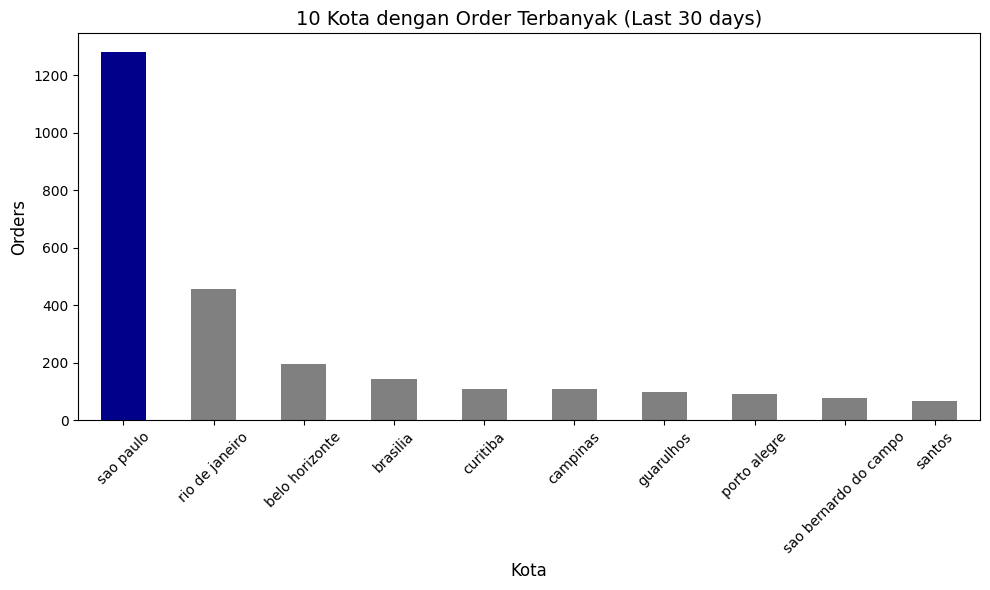

In [40]:
city_order_count = recentorders.groupby('customer_city').order_id.nunique().sort_values(ascending=False)
colors =["#00008B","#808080","#808080","#808080","#808080","#808080","#808080","#808080","#808080","#808080"]

plt.figure(figsize=(10, 6))
city_order_count.head(10).plot(kind='bar', color=colors)
plt.title('10 Kota dengan Order Terbanyak (Last 30 days)', fontsize=14)
plt.xlabel('Kota', fontsize=12)
plt.ylabel('Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana **Performa Penjualan Produk** dalam kurun tahun 2016 - 2018?

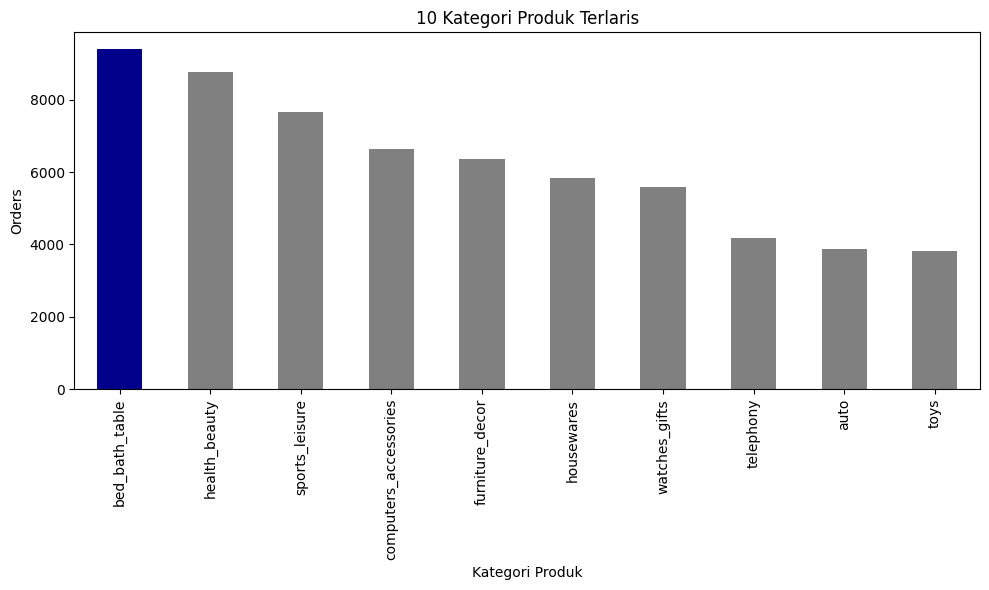

In [41]:
category_order_counts = merged_df.groupby(by="product_category_name_english").order_id.nunique().sort_values(ascending=False)
top_10_categories = category_order_counts.head(10)
colors =["#00008B","#808080","#808080","#808080","#808080","#808080","#808080","#808080","#808080","#808080"]

plt.figure(figsize=(10, 6))
top_10_categories.plot(kind='bar', color=colors)
plt.title("10 Kategori Produk Terlaris")
plt.xlabel("Kategori Produk")
plt.ylabel("Orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Pertanyaan 3: **Kategori Produk Apa** yang menghasilkan **Pendapatan Terbanyak** dalam kurun waktu 6 bulan terakhir?

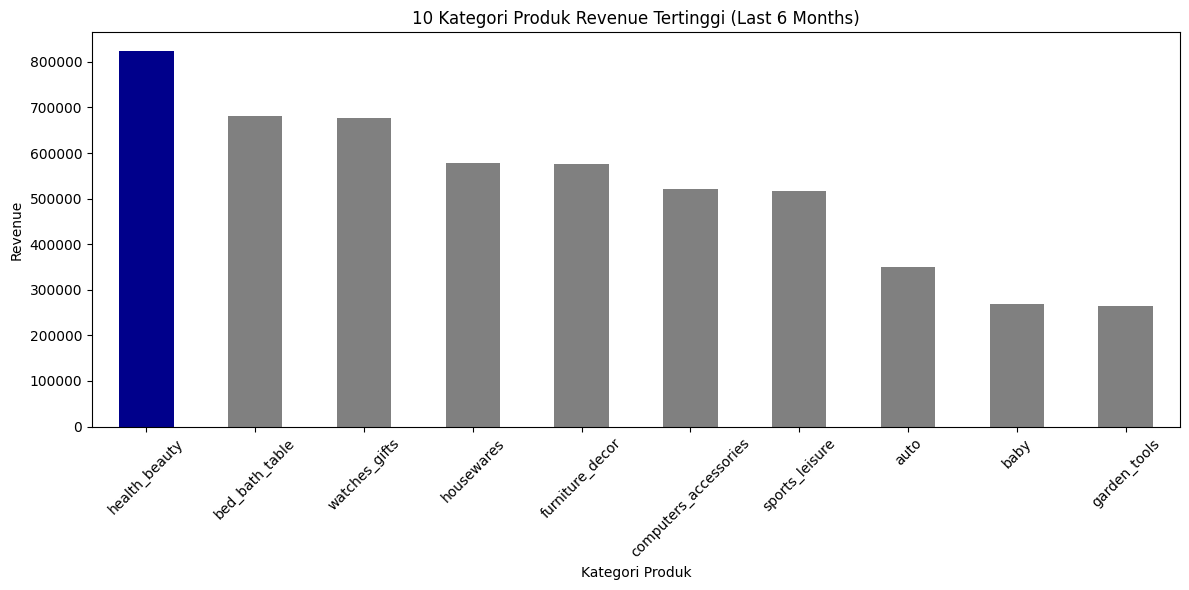

In [42]:
category_payment_sum = sixmonthorders.groupby(by="product_category_name_english").payment_value.sum().sort_values(ascending=False)
top_10_categories = category_payment_sum.head(10)
colors =["#00008B","#808080","#808080","#808080","#808080","#808080","#808080","#808080","#808080","#808080"]

plt.figure(figsize=(12, 6))
top_10_categories.plot(kind='bar', color=colors)
plt.title("10 Kategori Produk Revenue Tertinggi (Last 6 Months)")
plt.xlabel("Kategori Produk")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**
- Seluruh Pertanyaan cocok divisualisasikan menggunakan **Bar Chart** karena dapat dengan mudah menghighlight data yang memiliki nilai tertinggi

## Analisis Lanjutan (Opsional)

Tujuan **RFM** menjadi patokan dari tujuan utama yang diangkat dan dijadikan pertanyaan adalah karena Keseluruhan Aspek RFM sangat penting bagi Bisnis seperti E-commerce untuk menentukan langkah *advertising* berikutnya dan juga mengetahui bagaimana tipe pelanggan setia mereka serta apa yang mereka sukai.

## Conclusion

- Pertanyaan 1 : Sao Paulo merupakan kota yang memiliki pelanggan - pelanngan dengan jumlah pembelian terbanyak dalam 30 hari terakhir, tidak heran melihat Sao Paulo merupakan kota terbesar di Brazil
- Pertanyaan 2 : bed_bath_table menempati Posisi 1 produk Terlaris selama kurun waktu 2 tahun terakhir yang dibeli secara online secara di Brazil
- Pertanyaan 3 : Meskipun bed_bath_table menempati posisi 1 Terlaris dalam 2 tahun terakhir, health_beauty-lah yang menghasilkan revenue tertinggi dalam 6 bulan terakhir